# Linear Regression: electricity consumption <-> interor-outerior temperaure difference , sun factor

NOTE: our aim here is just to obtain a rough understanding of the relations, not a true predictive model. 
So no test, train split is done, nor any scaling of the features.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

import os

PATH_DATA = "transformed_data/"
PATH_PLOT = "plots/"

os.makedirs(PATH_PLOT, exist_ok=True)

In [2]:
df = pd.read_csv(PATH_DATA + "data_grid_pv_transformed_subset.csv")

## Consideration
Since the consumption pattern is different between winter time and rest of the year. I split the analysis in two parts.
The separation is done by temperature difference. If $\Delta T < -11$ I define it as winter time, otherwise not winter time.

## OLS, only temperature difference as a predecting variable

In [3]:
y_winter = df[df["temperature_diff"] < -11 ]["consumption"]
X_winter = df[df["temperature_diff"] < -11 ]["temperature_diff"]
X_winter = sm.add_constant(X_winter)
model_winter = sm.OLS(y_winter , X_winter)
results_winter = model_winter.fit()
summary_winter = results_winter.summary()



y_not_winter = df[df["temperature_diff"] >= -11 ]["consumption"]
X_not_winter = df[df["temperature_diff"] >= -11 ]["temperature_diff"]
X_not_winter = sm.add_constant(X_not_winter)
model_not_winter = sm.OLS(y_not_winter , X_not_winter)
results_not_winter = model_not_winter.fit()
summary_not_winter = results_not_winter.summary()

In [4]:
results_winter.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            consumption   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     797.6
Date:                Mon, 21 Sep 2026   Prob (F-statistic):          2.61e-119
Time:                        21:28:22   Log-Likelihood:                -2731.5
No. Observations:                 735   AIC:                             5467.
Df Residuals:                     733   BIC:                             5476.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.4706      1.357      4.032      0.000       2.807       8.134
temperature_diff    -1.8706      0.066    -28.242      0.000      -2.001      -1.741
==============================================================================
Omnibus:                       97.019   Durbin-Watson:                   1.346
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              153.335
Skew:                           0.872   Prob(JB):                     5.06e-34
Kurtosis:                       4.401   Cond. No.                         75.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
results_not_winter.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            consumption   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     10.22
Date:                Mon, 21 Sep 2026   Prob (F-statistic):            0.00148
Time:                        21:28:23   Log-Likelihood:                -1711.6
No. Observations:                 506   AIC:                             3427.
Df Residuals:                     504   BIC:                             3436.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               17.6989      0.627     28.214      0.000      16.466      18.931
temperature_diff    -0.3273      0.102     -3.197      0.001      -0.528      -0.126
==============================================================================
Omnibus:                      140.271   Durbin-Watson:                   1.549
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              559.763
Skew:                           1.201   Prob(JB):                    2.81e-122
Kurtosis:                       7.559   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
def plot_reg(results, X, y, x_pos):
    intercept = results.params.iloc[0]
    slope = results.params.iloc[1]
    r_squared = results.rsquared

    X_plot = X["temperature_diff"]

    season = "winter" if X_plot.max() < - 11 else "not_winter"

    plt.figure(figsize=(10, 6))
    plt.scatter(X_plot, y, color='blue', alpha=0.6)
    plt.plot(X_plot, results.fittedvalues, color='red', linewidth=2, label='linear regression best fit')


    equation_text = f'Cosumption = {slope:.2f} * $\Delta T$ + {intercept:.2f}'
    plt.text(x_pos , np.max(y)*0.95, equation_text, fontsize=11, color='darkred',
              bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

    plt.title('Consumption Variance Explained By $\Delta T = (T - 21) [\degree C] $')
    plt.xlabel('$\Delta T = (T - 21) [\degree C] $')
    plt.ylabel('Consumption [kWh]')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(PATH_PLOT + f'consumption_temperature_ols_{season}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

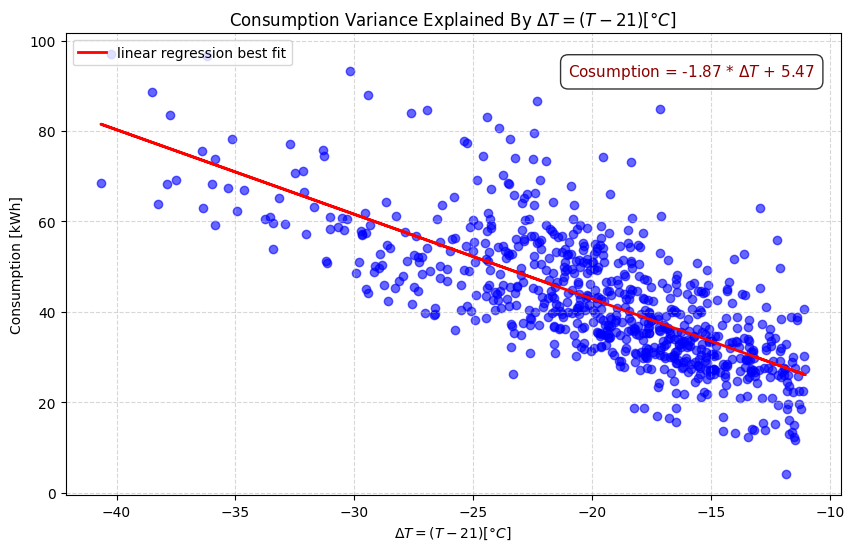

In [21]:
plot_reg(results_winter, X_winter, y_winter, -21) 

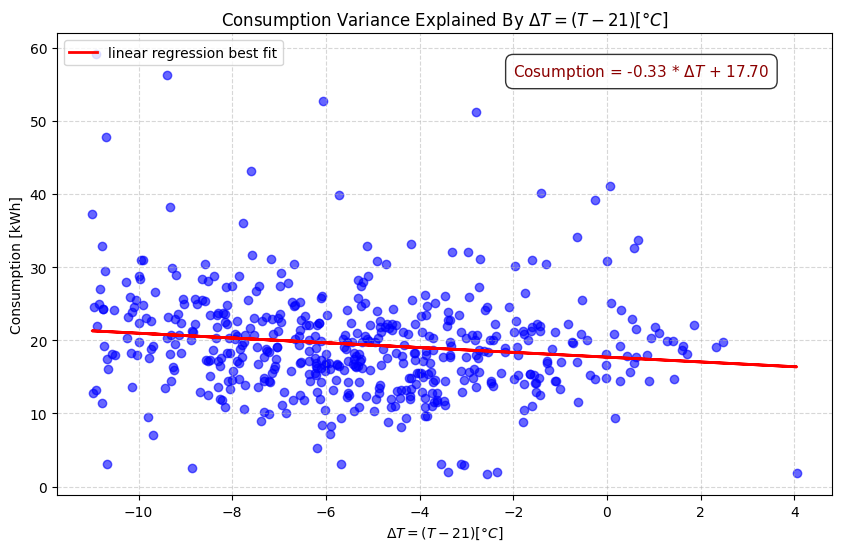

In [22]:
plot_reg(results_not_winter, X_not_winter, y_not_winter, -2) 

## Multi Linear Regression, both temperature difference and sun factor as predicting variables

In [4]:
df_mlr = df[["consumption","temperature_diff","sun_factor"]]

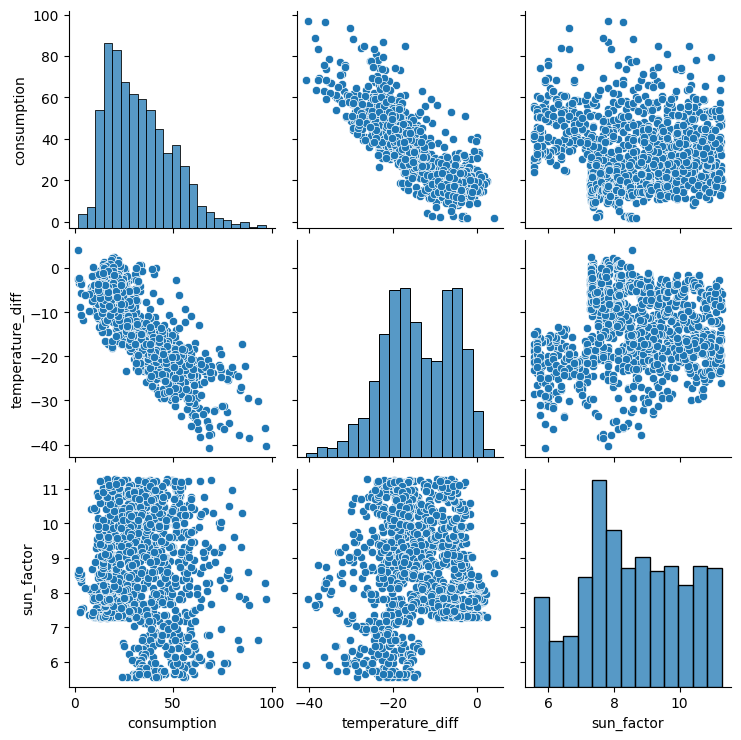

In [6]:
sns.pairplot(df_mlr)

In [8]:
X = df_mlr[["temperature_diff","sun_factor"]]
X = sm.add_constant(X)
y= df_mlr["consumption"]

model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
print("Coefficients (Slopes):", model.coef_) 
print("Intercept (Bias):", model.intercept_)

Coefficients (Slopes): [ 0.         -1.59310125  0.17713944]
Intercept (Bias): 9.445637027116764
